In [1]:
### Wczytanie i diagnostyka braków

In [3]:
import pandas as pd
import numpy as np

df = pd.read_excel(
    "default_of_credit_card_clients.xls",
    header=1,
    engine="xlrd"
)

df.rename(columns={"default payment next month": "default"}, inplace=True)

df.isna().sum().sort_values(ascending=False).head()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
dtype: int64

### feature engeniring

In [5]:
bpay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

df["AVG_BILL_AMT"] = df[bill_cols].mean(axis=1)
df["AVG_PAY_AMT"] = df[pay_amt_cols].mean(axis=1)

df["MAX_DELAY"] = df[pay_cols].max(axis=1)
df["NUM_DELAYS"] = (df[pay_cols] > 0).sum(axis=1)

df["UTILIZATION"] = df["AVG_BILL_AMT"] / (df["LIMIT_BAL"] + 1)

### podział na X i y

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["default", "ID"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


### Pipeline preprocessing

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_cols = X.columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
])

### Modele

In [8]:
# Bazowy - regresja
from sklearn.linear_model import LogisticRegression

lr = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [9]:
from sklearn.tree import DecisionTreeClassifier

dt = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=100,
        random_state=42
    ))
])

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=50,
        n_jobs=-1,
        random_state=42
    ))
])

### ewaluacja

In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

def evaluate(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

In [12]:
evaluate(lr, "Logistic Regression")
evaluate(dt, "Decision Tree")
evaluate(rf, "Random Forest")


Logistic Regression
Accuracy : 0.8085
Precision: 0.6861924686192469
Recall   : 0.24717407686510928
F1-score : 0.3634349030470914
ROC-AUC  : 0.7280776175599343

Decision Tree
Accuracy : 0.8155
Precision: 0.6558073654390935
Recall   : 0.34890730972117556
F1-score : 0.45548450565666504
ROC-AUC  : 0.7440180897783625

Random Forest
Accuracy : 0.818
Precision: 0.6657263751763046
Recall   : 0.3556895252449133
F1-score : 0.4636542239685658
ROC-AUC  : 0.7783603832305743


### selecja zmiennych

In [13]:
importances = rf.named_steps["model"].feature_importances_

fi = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(10)

,feature,importance
5,PAY_0,0.304256
6,PAY_2,0.161204
7,PAY_3,0.076740
8,PAY_4,0.065347
9,PAY_5,0.048047
10,PAY_6,0.037963
27,UTILIZATION,0.030037
26,NUM_DELAYS,0.027711
24,AVG_PAY_AMT,0.027433
17,PAY_AMT1,0.024393


### tunning hyper parametrów

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

num_cols = X.columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
])

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

In [29]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    "model__n_estimators": randint(200, 500),
    "model__max_depth": randint(6, 20),
    "model__min_samples_leaf": randint(20, 150),
    "model__min_samples_split": randint(2, 20),
    "model__max_features": ["sqrt", "log2", 0.5]
}

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=35,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rs.fit(X_train, y_train)

best_model = rs.best_estimator_

Fitting 5 folds for each of 35 candidates, totalling 175 fits


In [30]:
print(rs.cv_results_["mean_test_score"])

[0.78678722 0.7841968  0.78613378 0.78271253 0.78607237 0.78613308
 0.78598326 0.78608717 0.78633313 0.78633386 0.7846667  0.78588216
 0.78264483 0.78528045 0.78346545 0.78575515 0.7855418  0.78682119
 0.7863559  0.78526736 0.78421471 0.78533485 0.78007932 0.78185574
 0.78576339 0.78649462 0.78546362 0.7858716  0.78267805 0.77995615
 0.78459614 0.78218239 0.77919981 0.7833528  0.78367015]


In [31]:
best_model = rs.best_estimator_

print("Best ROC-AUC:", rs.best_score_)
print("Best params:")
rs.best_params_

Best ROC-AUC: 0.7868211883125431
Best params:


{'model__max_depth': 13,
 'model__max_features': 0.5,
 'model__min_samples_leaf': 52,
 'model__min_samples_split': 6,
 'model__n_estimators': 430}

### Ewaluacja na zbiorze testowym

In [32]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Test ROC-AUC: 0.7777650022068768
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      4673
           1       0.49      0.60      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.78      6000



### conf matrix

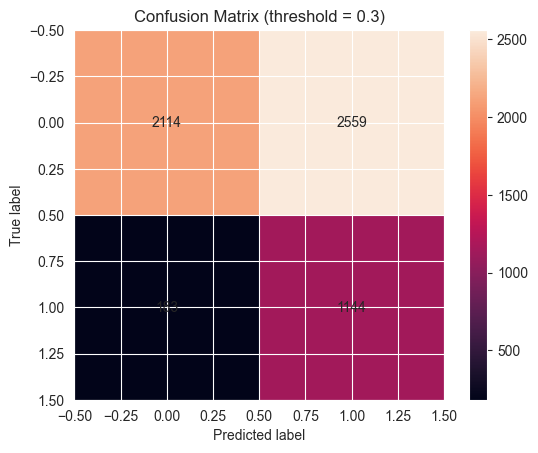

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

threshold = 0.3
y_pred_thr = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_thr)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (threshold = 0.3)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

### ROC

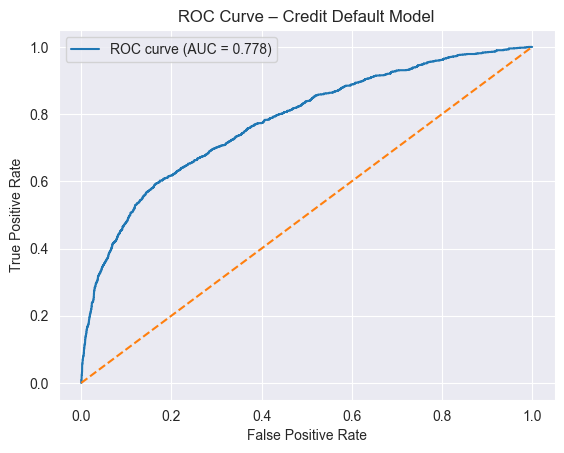

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Credit Default Model")
plt.legend()
plt.show()

### precision-recall

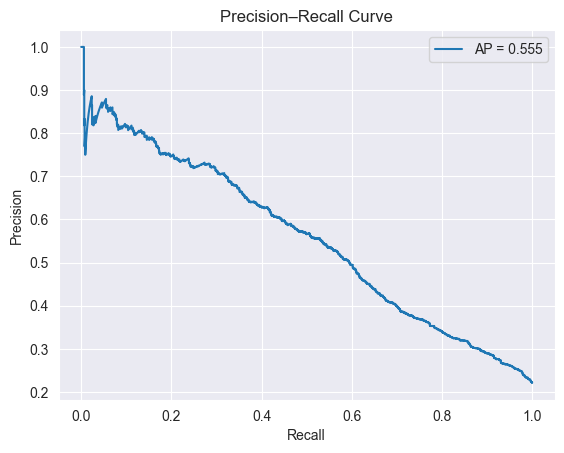

In [35]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

### serializacja i zapisanie

In [36]:
import joblib
from datetime import datetime

# opcjonalnie: wersjonowanie
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

model_path = f"credit_default_model_{timestamp}.joblib"

joblib.dump(best_model, model_path)

print(f"Model zapisany do pliku: {model_path}")

Model zapisany do pliku: credit_default_model_20260201_220347.joblib


### parametry i metryki

In [38]:
import json

metadata = {
    "model_type": "RandomForestClassifier",
    "best_params": best_model.named_steps["model"].get_params(),
    "roc_auc_test": roc_auc_score(y_test, y_prob),
    "threshold": 0.3,
    "features": X.columns.tolist()
}

with open(f"credit_default_model_{timestamp}_meta.json", "w") as f:
    json.dump(metadata, f, indent=4)